In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [2]:
# Data Preprocessing:
df = pd.read_excel("/content/EastWestAirlines (2).xlsx", sheet_name="data")
df

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


In [4]:
df = df.drop("ID#", axis=1)
df

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...
3994,18476,0,1,1,1,8525,4,200,1,1403,1
3995,64385,0,1,1,1,981,5,0,0,1395,1
3996,73597,0,3,1,1,25447,8,0,0,1402,1
3997,54899,0,1,1,1,500,1,500,1,1401,0


In [5]:
#handling missing value
df.isnull().sum()

,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0
Days_since_enroll,0


In [6]:
#In this datasets null value is not present

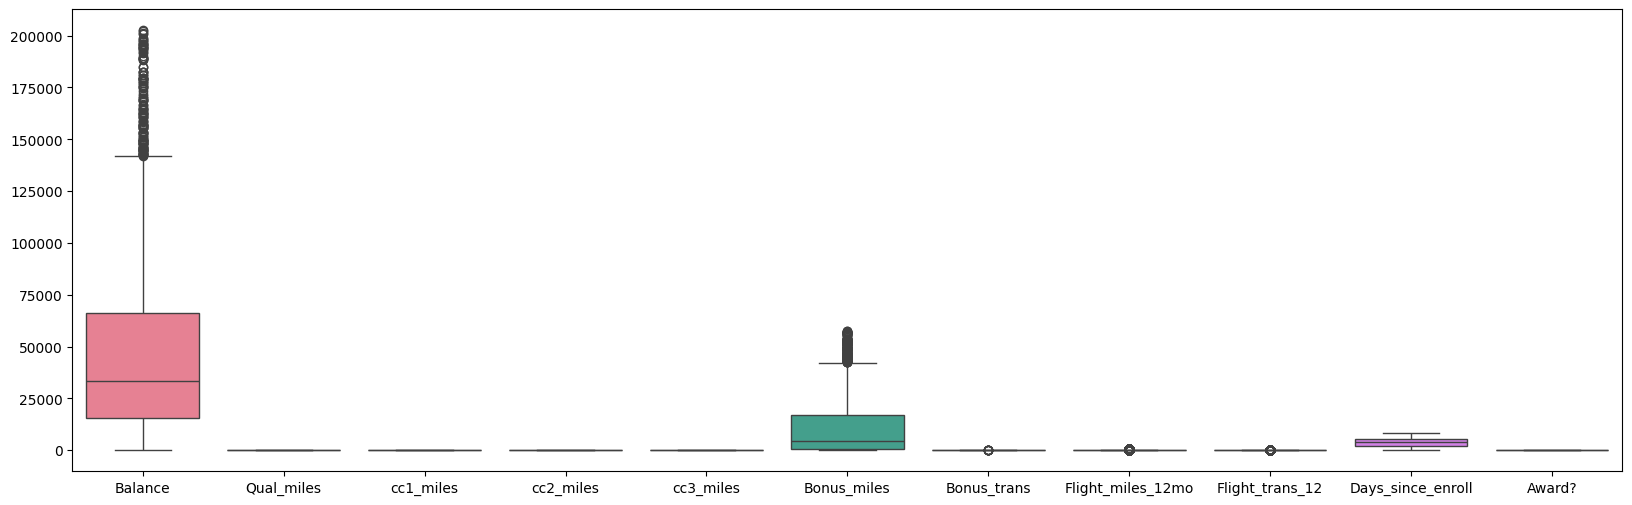

In [40]:
#remove outliers
plt.figure(figsize=(20,6))
sns.boxplot(data=df)
plt.show()

In [41]:
#Outlier detection using Isolation Forest
iso_forest = IsolationForest(contamination=0.01, random_state=42)
outlier_predictions = iso_forest.fit_predict(df)

outlier_indices = df.index[outlier_predictions == -1]

print(f"Number of detected outliers: {len(outlier_indices)}")

Number of detected outliers: 29


In [42]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Create a mask for values inside allowed range
mask = ~((df[num_cols] < (Q1 - 1.5 * IQR)) |
         (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

df = df[mask]

print("After removing outliers:", df.shape)

After removing outliers: (2226, 11)


In [43]:
df

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
5,16420,0,1,1,1,0,0,0,0,6942,0
...,...,...,...,...,...,...,...,...,...,...,...
3992,11181,0,1,1,1,929,12,0,0,1407,0
3993,3974,0,1,1,1,365,3,0,0,1397,0
3995,64385,0,1,1,1,981,5,0,0,1395,1
3996,73597,0,3,1,1,25447,8,0,0,1402,1


In [44]:
#StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaler = scaler.fit_transform(df)

df_scaler = pd.DataFrame(df_scaler, columns=df.columns)
df_scaler

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.283697,0.0,-0.648136,0.0,0.0,-0.765732,-1.002621,0.0,0.0,1.540129,-0.550707
1,-0.561675,0.0,-0.648136,0.0,0.0,-0.761816,-0.867046,0.0,0.0,1.524611,-0.550707
2,0.128974,0.0,-0.648136,0.0,0.0,-0.388530,-0.595896,0.0,0.0,1.556616,-0.550707
3,-0.701241,0.0,-0.648136,0.0,0.0,-0.734593,-1.002621,0.0,0.0,1.516853,-0.550707
4,-0.649888,0.0,-0.648136,0.0,0.0,-0.782352,-1.138196,0.0,0.0,1.512004,-0.550707
...,...,...,...,...,...,...,...,...,...,...,...
2221,-0.813538,0.0,-0.648136,0.0,0.0,-0.693616,0.488703,0.0,0.0,-1.172028,-0.550707
2222,-1.038663,0.0,-0.648136,0.0,0.0,-0.747488,-0.731471,0.0,0.0,-1.176878,-0.550707
2223,0.848392,0.0,-0.648136,0.0,0.0,-0.688649,-0.460322,0.0,0.0,-1.177847,1.815846
2224,1.136147,0.0,1.335028,0.0,0.0,1.648305,-0.053597,0.0,0.0,-1.174453,1.815846


In [45]:
# Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters
df_scaler.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226 entries, 0 to 2225
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Balance            2226 non-null   float64
 1   Qual_miles         2226 non-null   float64
 2   cc1_miles          2226 non-null   float64
 3   cc2_miles          2226 non-null   float64
 4   cc3_miles          2226 non-null   float64
 5   Bonus_miles        2226 non-null   float64
 6   Bonus_trans        2226 non-null   float64
 7   Flight_miles_12mo  2226 non-null   float64
 8   Flight_trans_12    2226 non-null   float64
 9   Days_since_enroll  2226 non-null   float64
 10  Award?             2226 non-null   float64
dtypes: float64(11)
memory usage: 191.4 KB


In [46]:
df.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,2226.000000,2226.0,2226.000000,2226.0,2226.0,2226.000000,2226.000000,2226.0,2226.0,2226.000000,2226.000000
mean,37225.105121,0.0,1.653639,1.0,1.0,8190.592093,8.395328,0.0,0.0,3823.952381,0.232704
std,32020.569243,0.0,1.008716,0.0,0.0,10471.536910,7.377650,0.0,0.0,2062.659374,0.422650
min,68.000000,0.0,1.000000,1.0,1.0,0.000000,0.000000,0.0,0.0,8.000000,0.000000
25%,12694.250000,0.0,1.000000,1.0,1.0,261.250000,1.000000,0.0,0.0,2032.750000,0.000000
50%,26952.000000,0.0,1.000000,1.0,1.0,3205.000000,8.000000,0.0,0.0,3708.500000,0.000000
75%,53036.750000,0.0,2.000000,1.0,1.0,13352.250000,14.000000,0.0,0.0,5458.000000,0.000000
max,141813.000000,0.0,4.000000,1.0,1.0,41854.000000,34.000000,0.0,0.0,8296.000000,1.000000


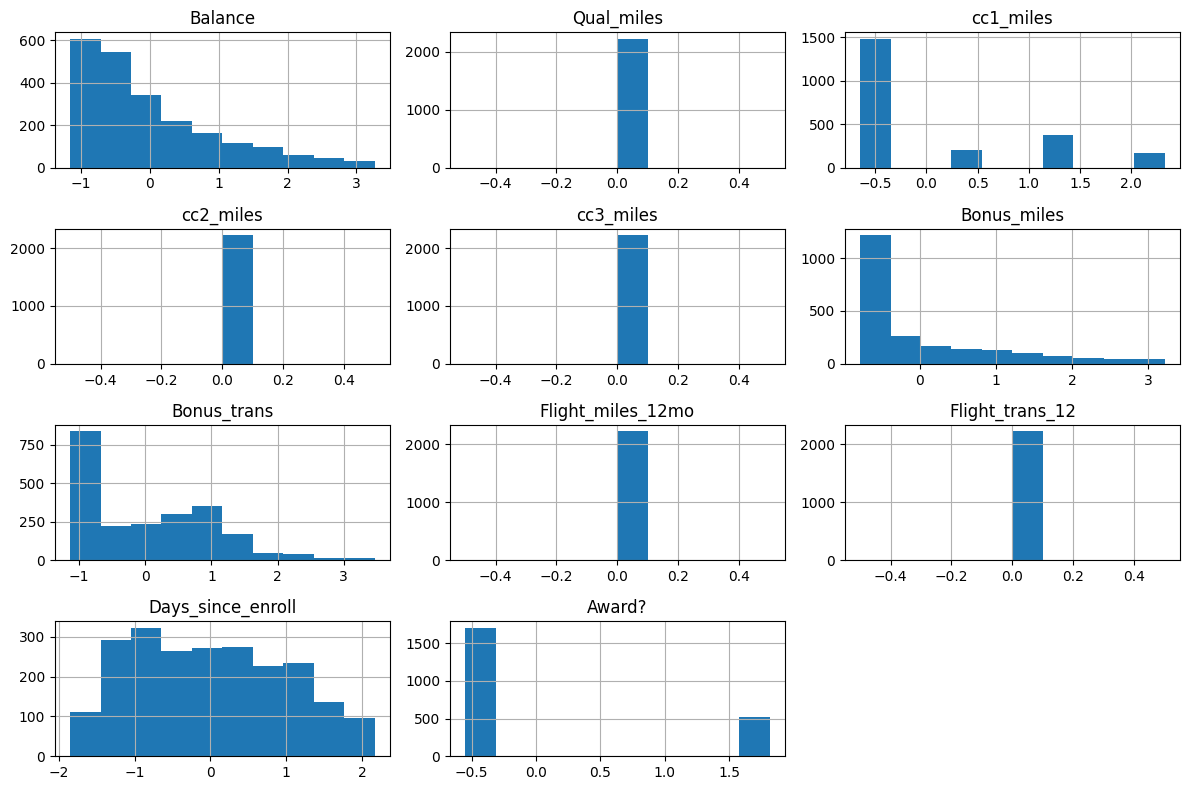

In [48]:
# Use multiple visualizations to understand the hidden patterns in the dataset
#Distribution Plot
df_scaler.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

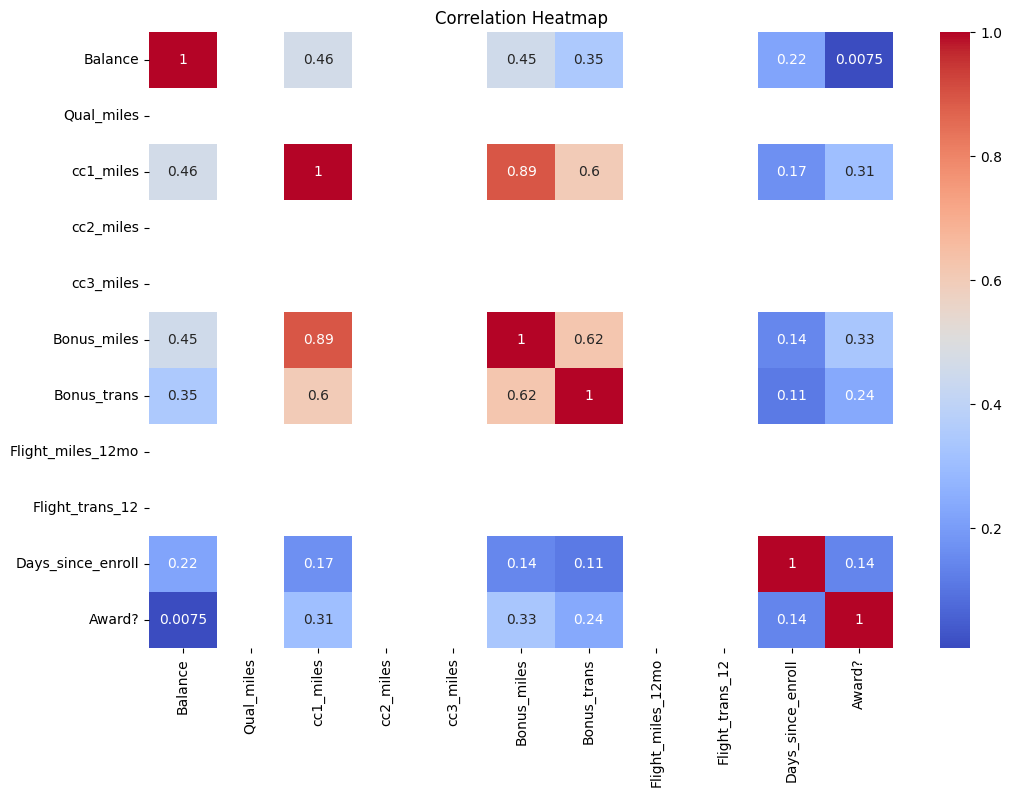

In [50]:
#Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_scaler.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

<Figure size 1200x800 with 0 Axes>

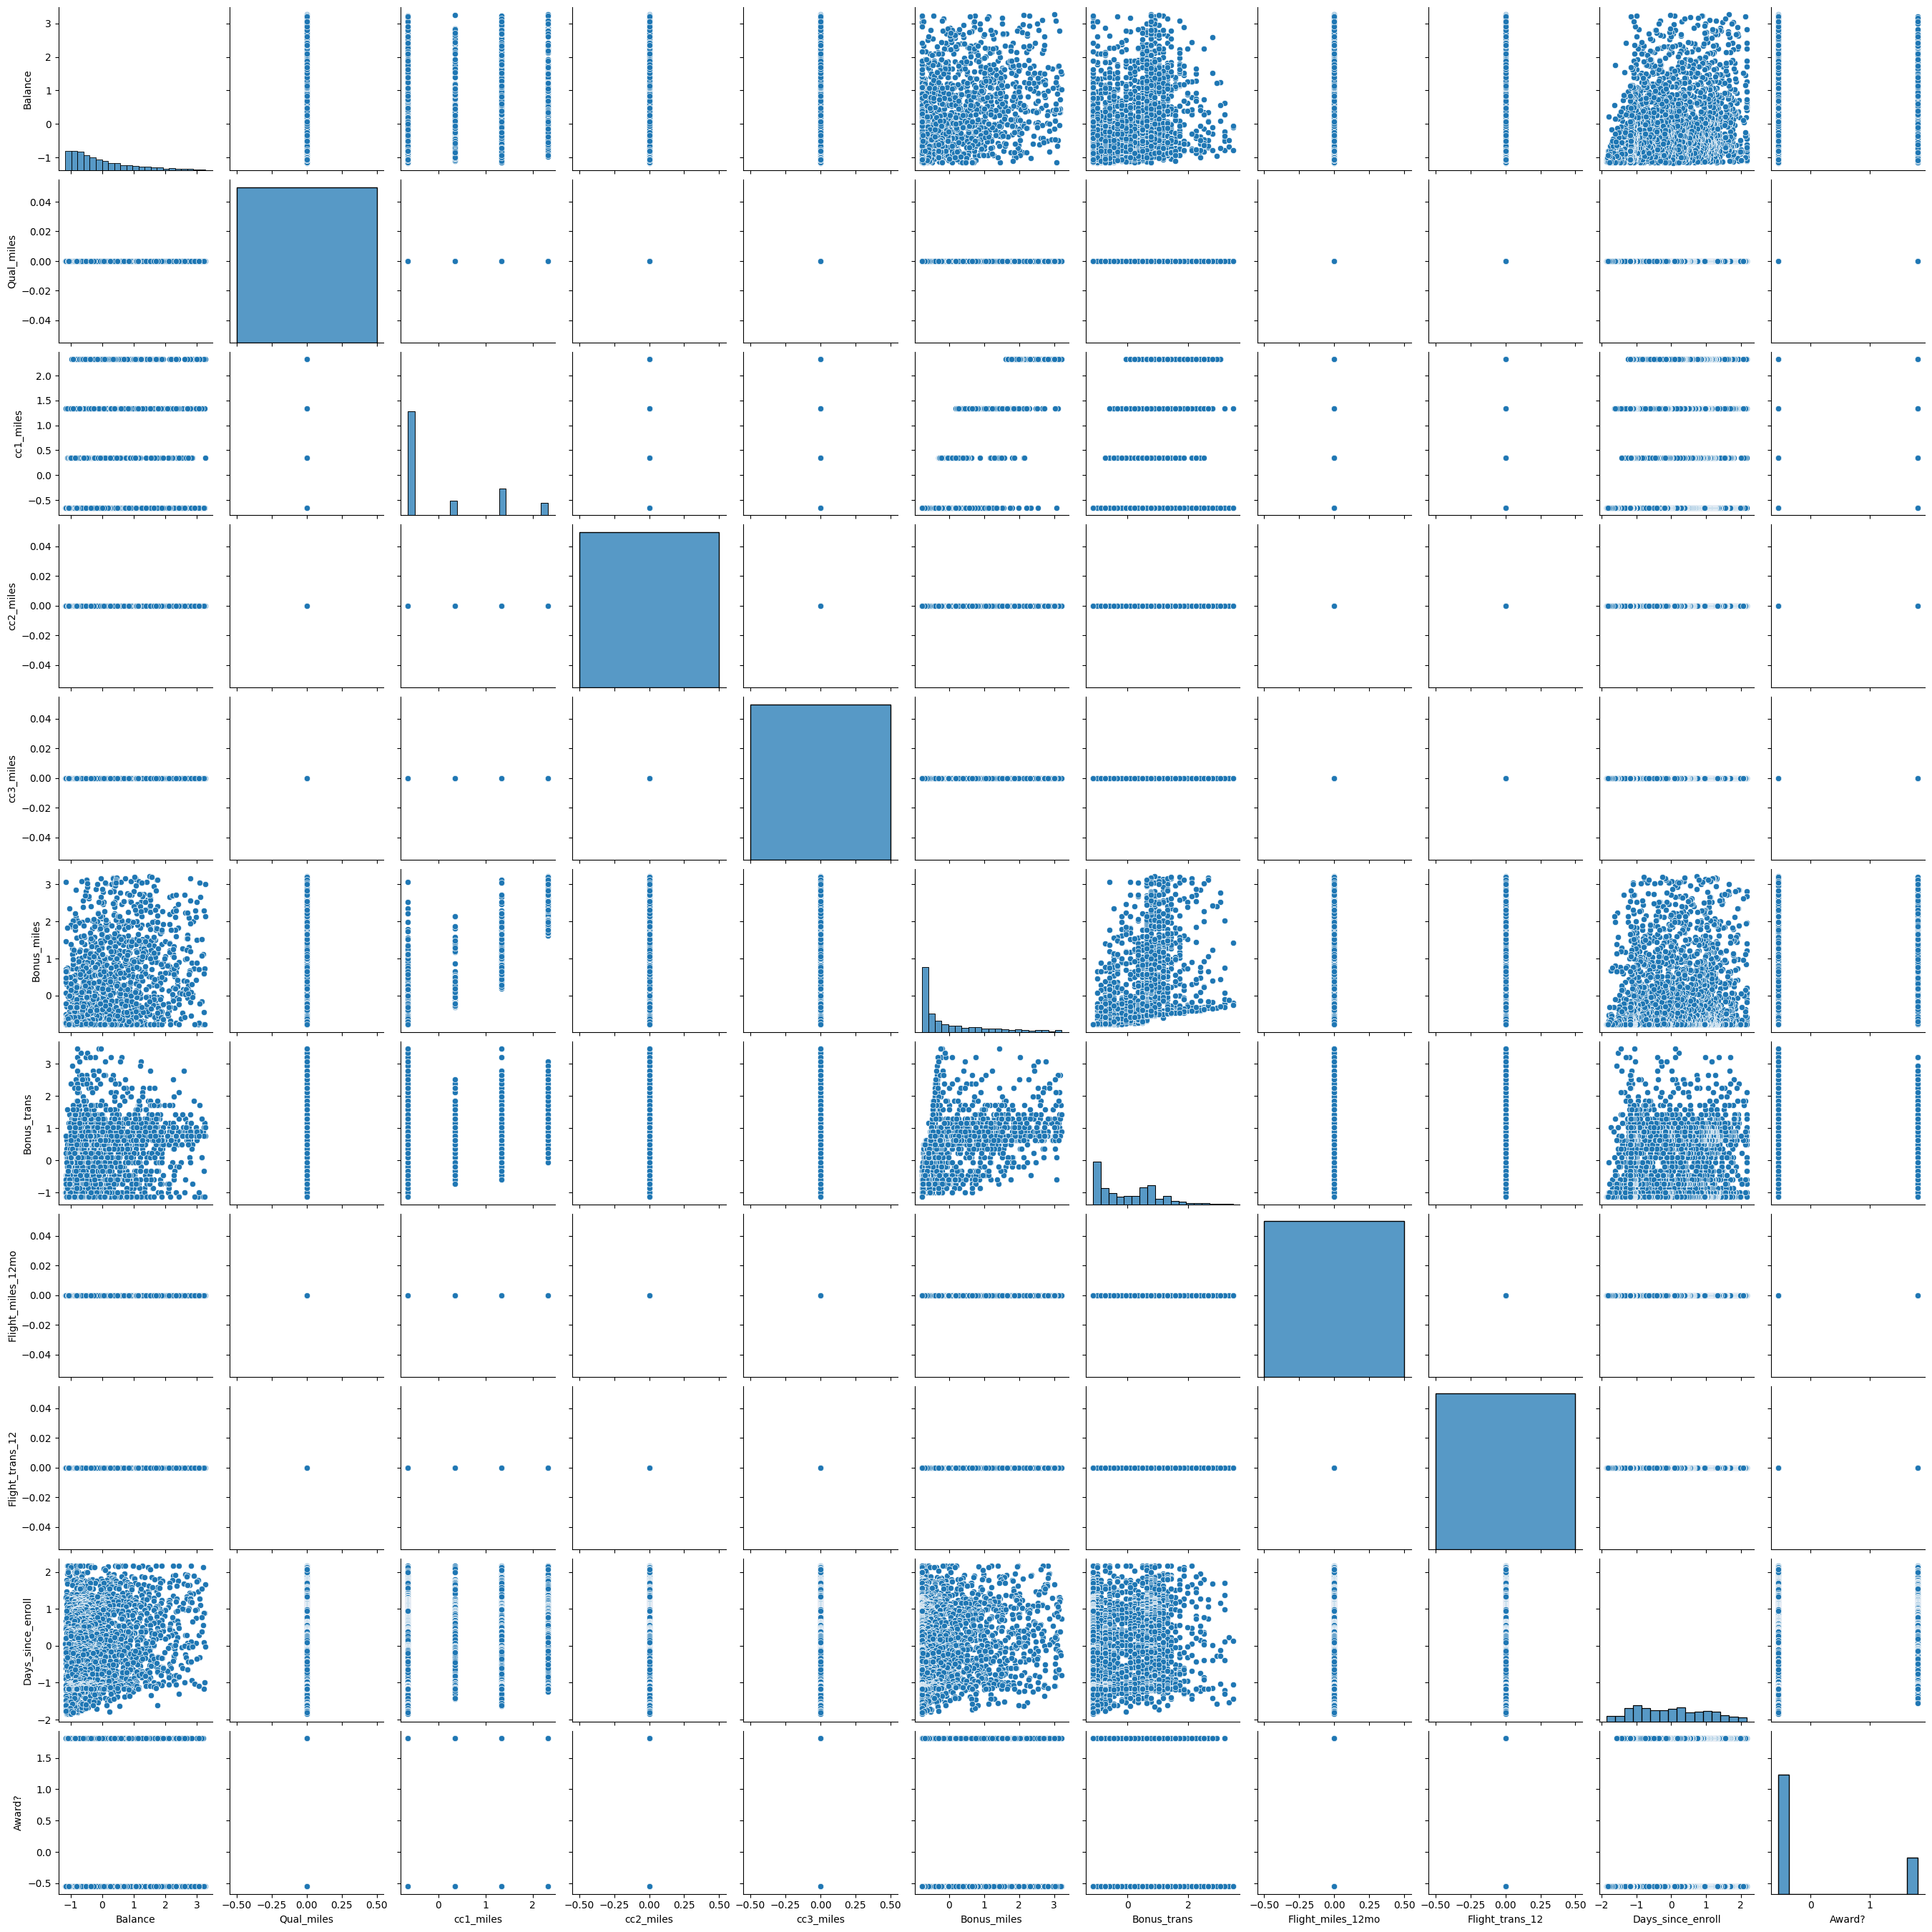

In [51]:
#PairPlot
plt.figure(figsize=(12,8))
sns.pairplot(df_scaler)
plt.show()

In [52]:
#Implementing Clustering Algorithms:

In [53]:
#Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [54]:
#Apply each clustering algorithm

#KMean clustering
kmean = KMeans(n_clusters=10, n_init=30)
kmean.fit(df_scaler)

KMeans(n_clusters=10, n_init=30)

In [55]:
kmean.inertia_

3367.7012470135687

In [56]:
kmean_label = kmean.predict(df_scaler)
kmean_label = pd.DataFrame(kmean_label)
kmean_label

,0
0,9
1,9
2,9
3,9
4,9
...,...
2221,8
2222,1
2223,4
2224,7


In [57]:
kmean_label[0].value_counts()

,count
0,
1,520
9,401
8,205
4,196
0,190
6,182
3,144
2,139
5,136


In [58]:
kmean_c = kmean.cluster_centers_
kmean_c

array([[-0.27974063,  0.        ,  0.8966439 ,  0.        ,  0.        ,
         0.71323632,  0.93966854,  0.        ,  0.        ,  0.20283959,
         1.81584617],
       [-0.63366219,  0.        , -0.64049423,  0.        ,  0.        ,
        -0.66498202, -0.8607771 ,  0.        ,  0.        , -0.96880681,
        -0.55070744],
       [ 1.95225936,  0.        ,  1.69884537,  0.        ,  0.        ,
         1.53435346,  0.99101352,  0.        ,  0.        ,  0.8780073 ,
        -0.39747735],
       [ 0.0489552 ,  0.        , -0.32449514,  0.        ,  0.        ,
        -0.23801616,  0.69677328,  0.        ,  0.        ,  0.97155012,
        -0.55070744],
       [-0.28523418,  0.        , -0.62790012,  0.        ,  0.        ,
        -0.42530263, -0.42781119,  0.        ,  0.        ,  0.15807236,
         1.81584617],
       [ 1.77802556,  0.        , -0.37107681,  0.        ,  0.        ,
        -0.23003893, -0.16125906,  0.        ,  0.        ,  0.10323973,
        -0.376

In [59]:
#DBSCAN
dbscan = DBSCAN(eps=2, min_samples=5)
dbscan.fit(df_scaler)

DBSCAN(eps=2)

In [60]:
dbscan.labels_

array([0, 0, 0, ..., 1, 1, 0])

In [61]:
dbscan_c=pd.DataFrame(dbscan.labels_,columns=['cluster'])
dbscan_c

,cluster
0,0
1,0
2,0
3,0
4,0
...,...
2221,0
2222,0
2223,1
2224,1


In [62]:
print(dbscan_c['cluster'].value_counts())

cluster
0    1708
1     518
Name: count, dtype: int64


In [64]:
#Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts)
#and evaluate the clustering results.

#K-means
inertia_list = []
silhouette_list = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaler)

    inertia_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(df_scaler, kmeans.labels_))

In [65]:
inertia_list

[8309.483301256892,
 7102.321708528184,
 6138.4781398476725,
 5280.719520615025,
 4473.217246323197,
 4181.00721068548,
 3792.9540809972127,
 3580.074073654743,
 3372.418281957462]

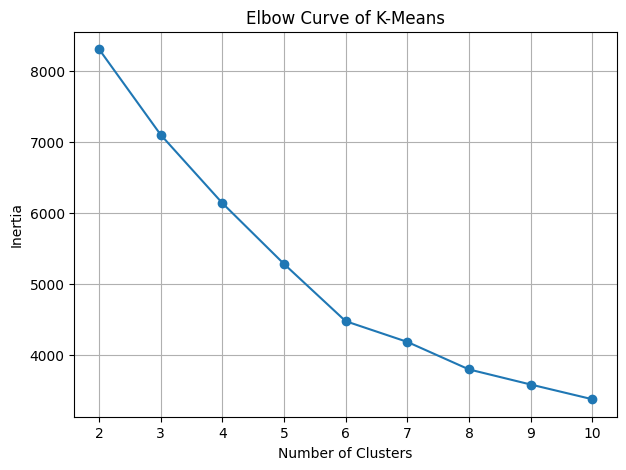

In [66]:
plt.figure(figsize=(7,5))
plt.plot(K_range, inertia_list, marker='o')
plt.title("Elbow Curve of K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

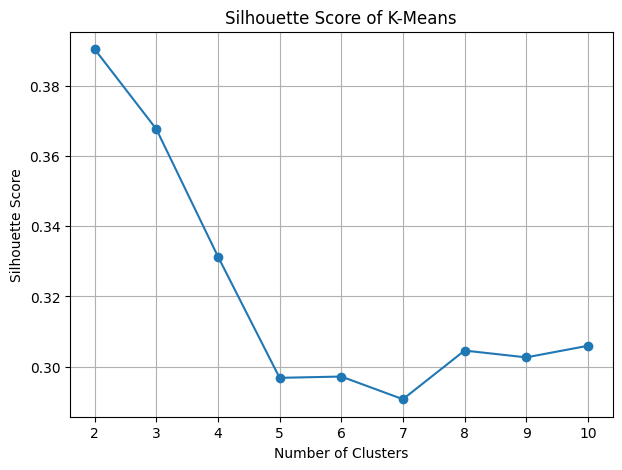

In [67]:
plt.figure(figsize=(7,5))
plt.plot(K_range, silhouette_list, marker='o')
plt.title("Silhouette Score of K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [69]:
#DBSCAN
from sklearn.metrics import silhouette_score
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [3, 5, 7]
silhouette_scores = []
eps_score = []

for eps in eps_values:
    for ms in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=ms)
        labels = dbscan.fit_predict(df_scaler)
        if len(set(labels)) <= 1:
            continue
        score = silhouette_score(df_scaler, labels)
        eps_score.append(eps)
        silhouette_scores.append(score)

In [70]:
eps_score

[0.2, 0.2, 0.2, 0.3, 0.3, 0.3, 0.4, 0.4, 0.4, 0.5, 0.5, 0.5, 0.6, 0.6, 0.6]

In [71]:
#Cluster Analysis and Interpretation:

In [72]:
#Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.

#   K-Mean Formed clear groups based on similar feature values. Clusters are well-separated and easy to interpret.

#   DBSCAN Found natural clusters based on data density. Detected outliers that K-Means missed.

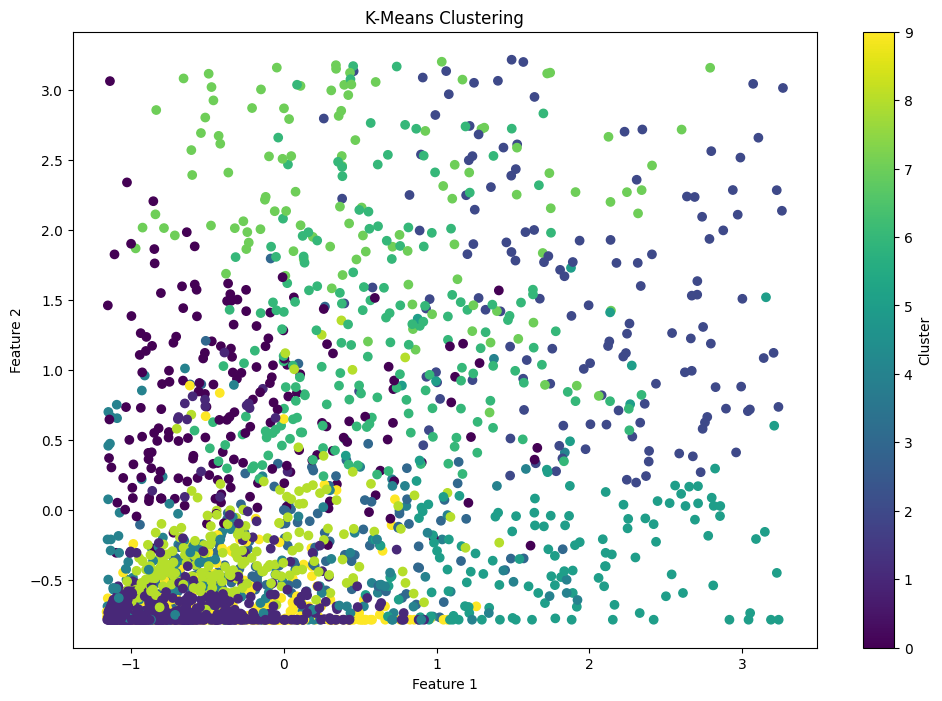

In [73]:
#K-Mean
plt.figure(figsize=(12,8))
plt.scatter(df_scaler.iloc[:,0], df_scaler.iloc[:,5], c=kmean_label, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Cluster")
plt.show()

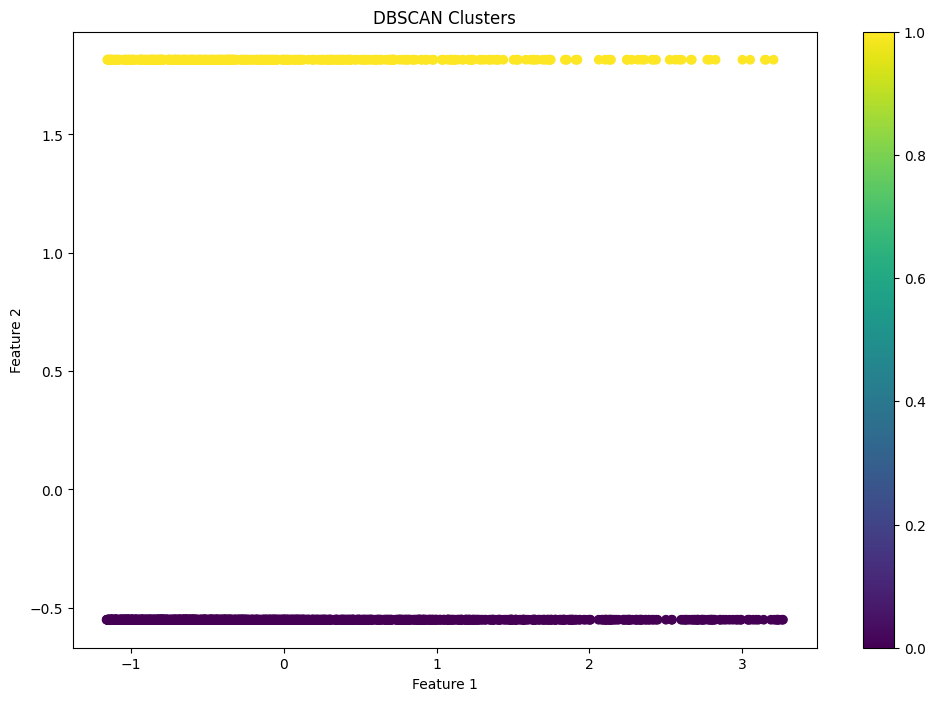

In [74]:
#DBSCAN
plt.figure(figsize=(12,8))
plt.scatter(df_scaler.iloc[:,0], df_scaler.iloc[:,10], c=dbscan_c.to_numpy(), cmap='viridis')
plt.title("DBSCAN Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar()
plt.show()

In [75]:
#Evaluation and Performance Metrics:

In [76]:
print("silhouette score of K-Mean",silhouette_list)

silhouette score of K-Mean [np.float64(0.390395409335517), np.float64(0.3676432454732502), np.float64(0.33133603233835096), np.float64(0.29680849501975526), np.float64(0.2971789406296137), np.float64(0.29072053968827904), np.float64(0.3045794356862182), np.float64(0.30263790483883934), np.float64(0.30593666268118774)]


In [77]:
print("silhouette score of DBSCAN", silhouette_scores)

silhouette score of DBSCAN [np.float64(-0.41066874303977735), np.float64(-0.2417852696660529), np.float64(-0.20671195388348013), np.float64(-0.44165924617333635), np.float64(-0.19156649505777232), np.float64(-0.15322317675183972), np.float64(-0.2394245445649643), np.float64(-0.26298581251108033), np.float64(-0.0016514689676433785), np.float64(-0.17486681036623924), np.float64(-0.12547855601752442), np.float64(-0.1530355345683285), np.float64(0.056083138642959836), np.float64(-0.05796185672537058), np.float64(0.02145333604312099)]
